In [1]:
import os
import json
import random
from dataclasses import dataclass
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import faiss
from sentence_transformers import SentenceTransformer
import torch


def set_seed(seed: int = 42) -> None:
    """Фиксация seed для воспроизводимости."""
    random.seed(seed)
    np.random.seed(seed)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

set_seed(42)

try:
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(42)
except ImportError:
    DEVICE = "cpu"

print(f"Device: {DEVICE}")

Device: cuda


Добросовестное замечение об использование AI: следующий датасет был создан при помощи LLM

In [2]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Списки в Python",
        "text": (
            "Список (list) — изменяемая упорядоченная коллекция элементов произвольных типов. "
            "Создаётся через квадратные скобки или конструктор list(). "
            "Поддерживает индексацию, срезы, методы append, extend, insert, pop и sort. "
            "Списки часто используются для хранения однородных последовательностей данных."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Словари в Python",
        "text": (
            "Словарь (dict) хранит пары ключ-значение и обеспечивает доступ по ключу за O(1). "
            "Ключи должны быть хэшируемыми, значения могут быть любого типа. "
            "Начиная с Python 3.7 словари сохраняют порядок вставки. "
            "Полезные методы: get, setdefault, update, keys, values, items."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Генераторы и итераторы",
        "text": (
            "Генератор — функция с ключевым словом yield, которая возвращает итератор. "
            "Генераторы вычисляют значения лениво, экономя память при работе с большими данными. "
            "Генераторное выражение создаётся через круглые скобки: (x**2 for x in range(10)). "
            "Протокол итератора требует методов __iter__ и __next__."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Декораторы",
        "text": (
            "Декоратор — функция, принимающая другую функцию и возвращающая обёртку. "
            "Синтаксис @decorator применяется перед определением функции. "
            "Стандартные декораторы: @staticmethod, @classmethod, @property, functools.lru_cache. "
            "Декораторы широко применяются для логирования, кэширования и проверки доступа."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Контекстные менеджеры",
        "text": (
            "Контекстный менеджер управляет ресурсами через оператор with. "
            "Он реализует методы __enter__ и __exit__ или используется через contextlib.contextmanager. "
            "Типичные примеры: открытие файлов, соединения с базами данных, блокировки потоков. "
            "with гарантирует корректное освобождение ресурсов даже при исключении."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Виртуальные окружения",
        "text": (
            "Виртуальное окружение изолирует зависимости проекта от системного Python. "
            "Создаётся через python -m venv или через инструменты вроде conda, poetry, uv. "
            "Активация окружения добавляет его bin/Scripts в PATH. "
            "Это позволяет разным проектам использовать разные версии одних и тех же библиотек."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Обработка исключений",
        "text": (
            "В Python исключения обрабатываются через конструкцию try/except/else/finally. "
            "Можно перехватывать конкретные типы исключений: ValueError, TypeError, KeyError и другие. "
            "Блок else выполняется, если исключение не возникло, finally — в любом случае. "
            "Собственные исключения создаются наследованием от Exception."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Типизация и аннотации типов",
        "text": (
            "Начиная с Python 3.5, доступны аннотации типов через модуль typing. "
            "Аннотации не влияют на выполнение, но помогают IDE и линтерам находить ошибки. "
            "Основные конструкции: List, Dict, Optional, Union, Tuple, Callable, TypeVar. "
            "Для проверки типов используются mypy, pyright и pytype."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Модуль collections",
        "text": (
            "Модуль collections предоставляет специализированные контейнеры: "
            "Counter для подсчёта элементов, defaultdict с значением по умолчанию, "
            "OrderedDict с гарантированным порядком, deque для двусторонних очередей, "
            "namedtuple для именованных кортежей. Эти структуры расширяют стандартные list и dict."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Работа с файлами",
        "text": (
            "Для чтения и записи файлов используется встроенная функция open(). "
            "Режимы открытия: 'r' (чтение), 'w' (запись), 'a' (дополнение), 'b' (бинарный). "
            "Рекомендуется использовать with open(...) as f для автоматического закрытия файла. "
            "Модуль pathlib предоставляет объектно-ориентированный интерфейс к файловой системе."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Многопоточность и GIL",
        "text": (
            "GIL (Global Interpreter Lock) ограничивает выполнение только одного потока Python одновременно. "
            "Для I/O-bound задач подходит модуль threading, для CPU-bound — multiprocessing. "
            "Начиная с Python 3.13 появился экспериментальный free-threaded режим без GIL. "
            "Модуль concurrent.futures предоставляет высокоуровневый интерфейс через ThreadPoolExecutor и ProcessPoolExecutor."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Dataclasses",
        "text": (
            "Декоратор @dataclass автоматически генерирует __init__, __repr__ и __eq__ для класса. "
            "Поля описываются как аннотации типов в теле класса. "
            "Параметры frozen=True, order=True и slots=True настраивают поведение класса. "
            "Dataclasses упрощают создание классов-контейнеров данных без шаблонного кода."
        ),
    },
    {
        "doc_id": "doc_13",
        "title": "Асинхронное программирование",
        "text": (
            "Модуль asyncio реализует событийный цикл для конкурентного выполнения корутин. "
            "Корутины определяются через async def, вызываются через await. "
            "asyncio.gather запускает несколько корутин параллельно. "
            "Асинхронный подход особенно эффективен для сетевых запросов и работы с API."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Тестирование в Python",
        "text": (
            "Стандартный модуль unittest предоставляет классы TestCase и методы assert. "
            "Фреймворк pytest популярен благодаря лаконичному синтаксису и мощным фикстурам. "
            "Тесты организуются по принципу AAA: Arrange, Act, Assert. "
            "Покрытие кода измеряется инструментом coverage, который интегрируется с pytest через pytest-cov."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Comprehensions",
        "text": (
            "List comprehension создаёт список в одну строку: [x**2 for x in range(10)]. "
            "Dict comprehension: {k: v for k, v in items}. Set comprehension: {x for x in data}. "
            "Вложенные comprehensions читаются слева направо, как вложенные циклы for. "
            "Comprehensions обычно быстрее эквивалентного цикла for, но теряют читаемость при сложной логике."
        ),
    },
]

docs_df: pd.DataFrame = pd.DataFrame(documents)
print(f"Документов в базе: {len(docs_df)}")
display(docs_df[["doc_id", "title"]].head(5))

for doc in documents[:3]:
    display(Markdown(f"**{doc['title']}**: {doc['text'][:120]}..."))

Документов в базе: 15


,doc_id,title
0,doc_01,Списки в Python
1,doc_02,Словари в Python
2,doc_03,Генераторы и итераторы
3,doc_04,Декораторы
4,doc_05,Контекстные менеджеры


**Списки в Python**: Список (list) — изменяемая упорядоченная коллекция элементов произвольных типов. Создаётся через квадратные скобки или к...

**Словари в Python**: Словарь (dict) хранит пары ключ-значение и обеспечивает доступ по ключу за O(1). Ключи должны быть хэшируемыми, значения...

**Генераторы и итераторы**: Генератор — функция с ключевым словом yield, которая возвращает итератор. Генераторы вычисляют значения лениво, экономя ...

In [3]:
def chunk_text(
    text: str,
    chunk_size: int = 25,
    overlap: int = 8,
) -> List[str]:
    """Разбиение текста на чанки по словам с перекрытием.

    Args:
        text: Исходный текст.
        chunk_size: Максимальное число слов в чанке.
        overlap: Число слов перекрытия между соседними чанками.

    Returns:
        Список текстовых фрагментов.

    Raises:
        ValueError: Если chunk_size <= 0 или overlap >= chunk_size.
    """
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть строго меньше chunk_size.")

    words: List[str] = text.replace("\n", " ").split()
    step: int = chunk_size - overlap
    chunks: List[str] = []

    for start in range(0, len(words), step):
        chunk_words: List[str] = words[start : start + chunk_size]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break

    return chunks


@dataclass
class ChunkRecord:
    """Один текстовый чанк с метаданными."""
    chunk_id: str
    doc_id: str
    title: str
    chunk_text: str
    chunk_index: int


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int = 25,
    overlap: int = 8,
) -> List[ChunkRecord]:
    """Создаёт список чанков из списка документов.

    Args:
        docs: Список документов с полями doc_id, title, text.
        chunk_size: Размер чанка в словах.
        overlap: Перекрытие в словах.

    Returns:
        Список ChunkRecord.
    """
    records: List[ChunkRecord] = []
    for doc in docs:
        chunks: List[str] = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for idx, chunk in enumerate(chunks):
            records.append(
                ChunkRecord(
                    chunk_id=f"{doc['doc_id']}_c{idx:02d}",
                    doc_id=doc["doc_id"],
                    title=doc["title"],
                    chunk_text=chunk,
                    chunk_index=idx,
                )
            )
    return records


chunks_list: List[ChunkRecord] = build_chunks(documents, chunk_size=25, overlap=8)
chunks_df: pd.DataFrame = pd.DataFrame([vars(c) for c in chunks_list])

print(f"Всего чанков: {len(chunks_df)}")
display(chunks_df.head(6))

example_doc: Dict[str, str] = documents[0]
example_chunks: List[str] = chunk_text(example_doc["text"], chunk_size=25, overlap=8)
print(f"\nДокумент: {example_doc['title']}")
print(f"Слов в документе: {len(example_doc['text'].split())}")
print(f"Чанков: {len(example_chunks)}")
for i, ch in enumerate(example_chunks):
    print(f"  Чанк {i}: {ch}")

Всего чанков: 31


,chunk_id,doc_id,title,chunk_text,chunk_index
0,doc_01_c00,doc_01,Списки в Python,Список (list) — изменяемая упорядоченная колле...,0
1,doc_01_c01,doc_01,Списки в Python,"индексацию, срезы, методы append, extend, inse...",1
2,doc_02_c00,doc_02,Словари в Python,Словарь (dict) хранит пары ключ-значение и обе...,0
3,doc_02_c01,doc_02,Словари в Python,могут быть любого типа. Начиная с Python 3.7 с...,1
4,doc_03_c00,doc_03,Генераторы и итераторы,"Генератор — функция с ключевым словом yield, к...",0
5,doc_03_c01,doc_03,Генераторы и итераторы,работе с большими данными. Генераторное выраже...,1



Документ: Списки в Python
Слов в документе: 34
Чанков: 2
  Чанк 0: Список (list) — изменяемая упорядоченная коллекция элементов произвольных типов. Создаётся через квадратные скобки или конструктор list(). Поддерживает индексацию, срезы, методы append, extend, insert, pop и
  Чанк 1: индексацию, срезы, методы append, extend, insert, pop и sort. Списки часто используются для хранения однородных последовательностей данных.


In [5]:
class EmbeddingBackend:
    """Абстрактный бэкенд для векторизации текстов."""

    backend_name: str = "abstract"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    """Dense-эмбеддинги через sentence-transformers."""

    def __init__(self, model_name: str, device: str = "cpu") -> None:
        self.model: SentenceTransformer = SentenceTransformer(model_name, device=device)
        self.backend_name: str = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors: np.ndarray = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors: np.ndarray = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype(np.float32)


class TfidfFallbackBackend(EmbeddingBackend):
    """TF-IDF fallback, если sentence-transformers недоступен."""

    def __init__(self) -> None:
        self.vectorizer: TfidfVectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name: str = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix: np.ndarray = self.vectorizer.fit_transform(texts).toarray().astype(np.float32)
        norms: np.ndarray = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
        return matrix / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix: np.ndarray = self.vectorizer.transform(texts).toarray().astype(np.float32)
        norms: np.ndarray = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
        return matrix / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    """Выбор лучшего доступного бэкенда."""
    try:
        backend: EmbeddingBackend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print(f"Бэкенд: {backend.backend_name}")
        return backend
    except Exception as exc:
        print(f"Dense-модель недоступна: {exc!r}")
    print("Используем TF-IDF fallback.")
    return TfidfFallbackBackend()


embedder: EmbeddingBackend = select_backend(device=DEVICE)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Бэкенд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [6]:
@dataclass
class RetrieverArtifacts:
    """Все компоненты retriever-а в одном объекте."""
    chunks_df: pd.DataFrame
    embeddings: np.ndarray
    index: faiss.Index
    embedder: EmbeddingBackend


def build_retriever(
    docs: List[Dict[str, str]],
    embedder: EmbeddingBackend,
    chunk_size: int = 25,
    overlap: int = 8,
) -> RetrieverArtifacts:
    """Полная сборка retriever: чанкинг → эмбеддинги → FAISS-индекс.

    Args:
        docs: Список документов.
        embedder: Бэкенд для эмбеддингов.
        chunk_size: Размер чанка.
        overlap: Перекрытие.

    Returns:
        RetrieverArtifacts с индексом и метаданными.
    """
    records: List[ChunkRecord] = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    df: pd.DataFrame = pd.DataFrame([vars(r) for r in records])
    texts: List[str] = df["chunk_text"].tolist()

    vectors: np.ndarray = embedder.fit_documents(texts)
    dim: int = vectors.shape[1]

    index: faiss.IndexFlatIP = faiss.IndexFlatIP(dim)
    index.add(vectors)

    print(f"Индекс FAISS: {index.ntotal} векторов, dim={dim}")
    return RetrieverArtifacts(chunks_df=df, embeddings=vectors, index=index, embedder=embedder)


artifacts: RetrieverArtifacts = build_retriever(documents, embedder, chunk_size=25, overlap=8)

Индекс FAISS: 31 векторов, dim=384


In [7]:
def search_chunks(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    """Поиск top-k наиболее релевантных чанков для запроса.

    Args:
        query: Текстовый запрос.
        artifacts: Собранный retriever.
        top_k: Число возвращаемых результатов.

    Returns:
        DataFrame с колонками: rank, score, chunk_id, doc_id, title, chunk_text.
    """
    query_vec: np.ndarray = artifacts.embedder.encode_queries([query])
    scores: np.ndarray
    indices: np.ndarray
    scores, indices = artifacts.index.search(query_vec, top_k)

    rows: List[Dict[str, Any]] = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        if idx < 0:
            continue
        row: pd.Series = artifacts.chunks_df.iloc[idx]
        rows.append({
            "rank": rank + 1,
            "score": float(score),
            "chunk_id": row["chunk_id"],
            "doc_id": row["doc_id"],
            "title": row["title"],
            "chunk_text": row["chunk_text"],
        })
    return pd.DataFrame(rows)


sample_queries: List[str] = [
    "Как создать список в Python?",
    "Что такое генератор и yield?",
    "Как работает декоратор?",
    "Зачем нужны виртуальные окружения?",
    "Как писать тесты с pytest?",
]

for q in sample_queries:
    display(Markdown(f"### Запрос: *{q}*"))
    result: pd.DataFrame = search_chunks(q, artifacts, top_k=3)
    display(result[["rank", "score", "doc_id", "title"]])

### Запрос: *Как создать список в Python?*

,rank,score,doc_id,title
0,1,0.607055,doc_01,Списки в Python
1,2,0.573992,doc_02,Словари в Python
2,3,0.519194,doc_08,Типизация и аннотации типов


### Запрос: *Что такое генератор и yield?*

,rank,score,doc_id,title
0,1,0.664020,doc_03,Генераторы и итераторы
1,2,0.378417,doc_04,Декораторы
2,3,0.353340,doc_03,Генераторы и итераторы


### Запрос: *Как работает декоратор?*

,rank,score,doc_id,title
0,1,0.394999,doc_03,Генераторы и итераторы
1,2,0.392875,doc_04,Декораторы
2,3,0.329316,doc_03,Генераторы и итераторы


### Запрос: *Зачем нужны виртуальные окружения?*

,rank,score,doc_id,title
0,1,0.638971,doc_06,Виртуальные окружения
1,2,0.345033,doc_06,Виртуальные окружения
2,3,0.250013,doc_05,Контекстные менеджеры


### Запрос: *Как писать тесты с pytest?*

,rank,score,doc_id,title
0,1,0.631714,doc_14,Тестирование в Python
1,2,0.606825,doc_14,Тестирование в Python
2,3,0.398341,doc_08,Типизация и аннотации типов


## 5. Контрольные запросы и оценка retrieval

In [8]:
benchmark_queries: List[Dict[str, Any]] = [
    {"query_id": "q01", "query": "Как создать и изменить список?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q02", "query": "Что такое словарь и как получить значение по ключу?", "relevant_doc_ids": ["doc_02"]},
    {"query_id": "q03", "query": "Чем генератор отличается от обычной функции?", "relevant_doc_ids": ["doc_03"]},
    {"query_id": "q04", "query": "Зачем нужен декоратор и как его написать?", "relevant_doc_ids": ["doc_04"]},
    {"query_id": "q05", "query": "Что делает оператор with?", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q06", "query": "Как изолировать зависимости проекта?", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q07", "query": "Как обрабатывать ошибки через try except?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q08", "query": "Зачем аннотации типов и как их проверять?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q09", "query": "Какие структуры данных есть в модуле collections?", "relevant_doc_ids": ["doc_09"]},
    {"query_id": "q10", "query": "Как читать и записывать файлы в Python?", "relevant_doc_ids": ["doc_10"]},
    {"query_id": "q11", "query": "Что такое GIL и как его обойти?", "relevant_doc_ids": ["doc_11"]},
    {"query_id": "q12", "query": "Как работает async/await и asyncio?", "relevant_doc_ids": ["doc_13"]},
]


def evaluate_retrieval(
    queries: List[Dict[str, Any]],
    artifacts: RetrieverArtifacts,
    top_k: int = 5,
) -> pd.DataFrame:
    """Оценка retrieval на benchmark-запросах.

    Считает hit@k, recall@k и MRR@k.

    Args:
        queries: Список запросов с полями query, relevant_doc_ids.
        artifacts: Собранный retriever.
        top_k: Число результатов.

    Returns:
        DataFrame с результатами для каждого запроса.
    """
    rows: List[Dict[str, Any]] = []

    for item in queries:
        query: str = item["query"]
        relevant: List[str] = item["relevant_doc_ids"]

        retrieved: pd.DataFrame = search_chunks(query, artifacts, top_k=top_k)
        retrieved_doc_ids: List[str] = retrieved["doc_id"].tolist()

        # hit@k — нашёлся ли хотя бы один релевантный документ в top-k
        hit: int = int(any(doc_id in retrieved_doc_ids for doc_id in relevant))

        # recall@k — доля найденных релевантных документов
        found_count: int = sum(1 for doc_id in relevant if doc_id in retrieved_doc_ids)
        recall: float = found_count / len(relevant) if relevant else 0.0

        # MRR@k — обратный ранг первого релевантного документа
        rank_first: Optional[int] = None
        for rank_idx, doc_id in enumerate(retrieved_doc_ids):
            if doc_id in relevant:
                rank_first = rank_idx + 1
                break
        mrr: float = (1.0 / rank_first) if rank_first else 0.0

        rows.append({
            "query_id": item["query_id"],
            "query": query,
            "expected_source": ", ".join(relevant),
            "retrieved_sources": ", ".join(retrieved_doc_ids),
            "hit_at_k": hit,
            "recall_at_k": recall,
            "mrr_at_k": mrr,
            "rank_of_first_relevant": rank_first,
        })

    return pd.DataFrame(rows)


eval_df: pd.DataFrame = evaluate_retrieval(benchmark_queries, artifacts, top_k=5)
display(eval_df)

summary: Dict[str, float] = {
    "mean_hit@5": float(eval_df["hit_at_k"].mean()),
    "mean_recall@5": float(eval_df["recall_at_k"].mean()),
    "mean_MRR@5": float(eval_df["mrr_at_k"].mean()),
}
print("\nСводные метрики retrieval:")
for k, v in summary.items():
    print(f"  {k}: {v:.3f}")

,query_id,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,mrr_at_k,rank_of_first_relevant
0,q01,Как создать и изменить список?,doc_01,"doc_01, doc_15, doc_02, doc_01, doc_09",1,1.0,1.000000,1
1,q02,Что такое словарь и как получить значение по к...,doc_02,"doc_02, doc_02, doc_15, doc_15, doc_05",1,1.0,1.000000,1
2,q03,Чем генератор отличается от обычной функции?,doc_03,"doc_03, doc_04, doc_03, doc_12, doc_15",1,1.0,1.000000,1
3,q04,Зачем нужен декоратор и как его написать?,doc_04,"doc_03, doc_04, doc_06, doc_06, doc_15",1,1.0,0.500000,2
4,q05,Что делает оператор with?,doc_05,"doc_03, doc_04, doc_03, doc_05, doc_15",1,1.0,0.250000,4
5,q06,Как изолировать зависимости проекта?,doc_06,"doc_06, doc_06, doc_05, doc_14, doc_14",1,1.0,1.000000,1
6,q07,Как обрабатывать ошибки через try except?,doc_07,"doc_07, doc_07, doc_08, doc_14, doc_14",1,1.0,1.000000,1
7,q08,Зачем аннотации типов и как их проверять?,doc_08,"doc_08, doc_14, doc_08, doc_12, doc_14",1,1.0,1.000000,1
8,q09,Какие структуры данных есть в модуле collections?,doc_09,"doc_09, doc_01, doc_12, doc_12, doc_01",1,1.0,1.000000,1
9,q10,Как читать и записывать файлы в Python?,doc_10,"doc_02, doc_08, doc_10, doc_11, doc_11",1,1.0,0.333333,3



Сводные метрики retrieval:
  mean_hit@5: 1.000
  mean_recall@5: 1.000
  mean_MRR@5: 0.840


## 6. Эксперимент с параметрами retrieval

Сравним два варианта `chunk_size`: 25 vs 40 слов (overlap пропорционально: 8 vs 12).

Индекс FAISS: 31 векторов, dim=384
Индекс FAISS: 16 векторов, dim=384


,chunk_size,overlap,n_chunks,mean_hit@5,mean_recall@5,mean_MRR@5
0,25,8,31,1.0,1.0,0.840278
1,40,12,16,1.0,1.0,0.861111


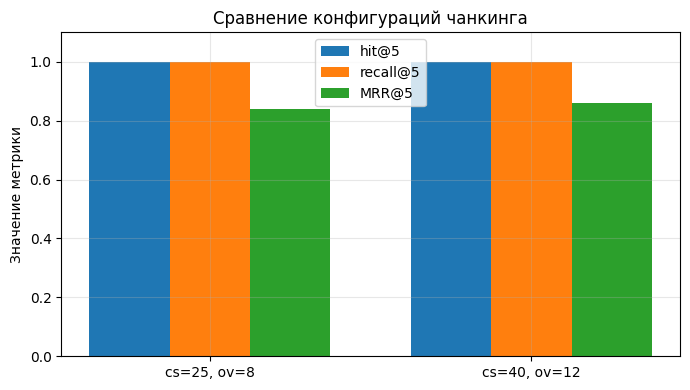

In [10]:
configs: List[Dict[str, int]] = [
    {"chunk_size": 25, "overlap": 8},
    {"chunk_size": 40, "overlap": 12},
]

experiment_results: List[Dict[str, Any]] = []

for cfg in configs:
    art: RetrieverArtifacts = build_retriever(
        documents, embedder, chunk_size=cfg["chunk_size"], overlap=cfg["overlap"]
    )
    ev: pd.DataFrame = evaluate_retrieval(benchmark_queries, art, top_k=5)
    experiment_results.append({
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "n_chunks": len(art.chunks_df),
        "mean_hit@5": float(ev["hit_at_k"].mean()),
        "mean_recall@5": float(ev["recall_at_k"].mean()),
        "mean_MRR@5": float(ev["mrr_at_k"].mean()),
    })

experiment_df: pd.DataFrame = pd.DataFrame(experiment_results)
display(experiment_df)

# Визуализация
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
x_labels: List[str] = [f"cs={r['chunk_size']}, ov={r['overlap']}" for r in experiment_results]
x_pos: np.ndarray = np.arange(len(x_labels))
width: float = 0.25

ax.bar(x_pos - width, [r["mean_hit@5"] for r in experiment_results], width, label="hit@5")
ax.bar(x_pos, [r["mean_recall@5"] for r in experiment_results], width, label="recall@5")
ax.bar(x_pos + width, [r["mean_MRR@5"] for r in experiment_results], width, label="MRR@5")
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение конфигураций чанкинга")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", dpi=150)
plt.show()

In [11]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_16",
        "title": "Модуль logging",
        "text": (
            "Модуль logging предоставляет гибкую систему логирования с уровнями DEBUG, INFO, WARNING, ERROR, CRITICAL. "
            "Логгеры организованы в иерархию по именам, каждый может иметь свои обработчики и форматтеры. "
            "В production-приложениях logging предпочтительнее print, потому что позволяет фильтровать и направлять сообщения."
        ),
    },
    {
        "doc_id": "doc_17",
        "title": "F-строки и форматирование",
        "text": (
            "F-строки (f'...') появились в Python 3.6 и позволяют встраивать выражения прямо в строку. "
            "Поддерживают спецификаторы формата: f'{value:.2f}', f'{name!r}', f'{num:>10}'. "
            "До f-строк использовались str.format() и оператор %. F-строки быстрее и читабельнее обоих."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Модуль functools",
        "text": (
            "Модуль functools содержит утилиты для работы с функциями высшего порядка. "
            "lru_cache кэширует результаты вызовов, partial фиксирует часть аргументов, "
            "reduce выполняет свёртку последовательности. "
            "singledispatch реализует перегрузку функций по типу первого аргумента."
        ),
    },
]

update_queries: List[str] = [
    "Как настроить логирование в Python?",
    "Что такое f-строки и как их использовать?",
    "Зачем нужен lru_cache из functools?",
]

before_results: Dict[str, List[str]] = {}
for q in update_queries:
    res: pd.DataFrame = search_chunks(q, artifacts, top_k=3)
    before_results[q] = res["doc_id"].tolist()
    print(f"ДО обновления | '{q}' → {res['doc_id'].tolist()}")

updated_documents: List[Dict[str, str]] = documents + new_documents
artifacts_updated: RetrieverArtifacts = build_retriever(
    updated_documents, embedder, chunk_size=25, overlap=8
)

after_results: Dict[str, List[str]] = {}
for q in update_queries:
    res = search_chunks(q, artifacts_updated, top_k=3)
    after_results[q] = res["doc_id"].tolist()
    print(f"ПОСЛЕ обновления | '{q}' → {res['doc_id'].tolist()}")

before_after_rows: List[Dict[str, Any]] = []
for q in update_queries:
    before_after_rows.append({
        "query": q,
        "before_retrieved_sources": ", ".join(before_results[q]),
        "after_retrieved_sources": ", ".join(after_results[q]),
        "changed": before_results[q] != after_results[q],
    })
ba_df: pd.DataFrame = pd.DataFrame(before_after_rows)
display(ba_df)

ДО обновления | 'Как настроить логирование в Python?' → ['doc_06', 'doc_02', 'doc_08']
ДО обновления | 'Что такое f-строки и как их использовать?' → ['doc_14', 'doc_14', 'doc_10']
ДО обновления | 'Зачем нужен lru_cache из functools?' → ['doc_04', 'doc_04', 'doc_06']
Индекс FAISS: 37 векторов, dim=384
ПОСЛЕ обновления | 'Как настроить логирование в Python?' → ['doc_16', 'doc_06', 'doc_02']
ПОСЛЕ обновления | 'Что такое f-строки и как их использовать?' → ['doc_17', 'doc_17', 'doc_14']
ПОСЛЕ обновления | 'Зачем нужен lru_cache из functools?' → ['doc_18', 'doc_04', 'doc_04']


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как настроить логирование в Python?,"doc_06, doc_02, doc_08","doc_16, doc_06, doc_02",True
1,Что такое f-строки и как их использовать?,"doc_14, doc_14, doc_10","doc_17, doc_17, doc_14",True
2,Зачем нужен lru_cache из functools?,"doc_04, doc_04, doc_06","doc_18, doc_04, doc_04",True


In [12]:
def split_into_sentences(text: str) -> List[str]:
    """Простое разбиение текста на предложения по точке, вопросу, восклицанию."""
    import re
    parts: List[str] = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in parts if len(s.strip()) > 5]


def generate_answer_from_context(
    query: str,
    context: str,
    max_sentences: int = 2,
) -> str:
    """Extractive-генератор ответа: выбирает предложения, наиболее близкие к запросу.

    Args:
        query: Вопрос пользователя.
        context: Собранный контекст из найденных чанков.
        max_sentences: Максимальное число предложений в ответе.

    Returns:
        Текст ответа.
    """
    raw_lines: List[str] = [
        line.strip()
        for line in context.splitlines()
        if line.strip() and not line.strip().startswith("[Источник:")
    ]
    sentence_pool: List[str] = []
    for line in raw_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для ответа."

    vectorizer: TfidfVectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix: np.ndarray = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec: np.ndarray = matrix[0:1]
    sent_vecs: np.ndarray = matrix[1:]
    scores: np.ndarray = cosine_similarity(query_vec, sent_vecs)[0]

    ranked_idx: np.ndarray = np.argsort(-scores)
    selected: List[str] = []
    used: set = set()

    for idx in ranked_idx:
        sentence: str = sentence_pool[idx]
        norm: str = sentence.lower().strip()
        if scores[idx] <= 0 or norm in used:
            continue
        used.add(norm)
        selected.append(sentence)
        if len(selected) >= max_sentences:
            break

    return " ".join(selected) if selected else "Не удалось найти подходящий ответ в контексте."


def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, Any]:
    """Полный mini-RAG: query → retrieval → context → answer → sources.

    Args:
        query: Вопрос пользователя.
        artifacts: Собранный retriever.
        top_k: Число фрагментов для контекста.
        max_answer_sentences: Максимум предложений в ответе.

    Returns:
        Словарь с полями query, answer, sources (DataFrame).
    """
    retrieved: pd.DataFrame = search_chunks(query, artifacts, top_k=top_k)

    context_blocks: List[str] = []
    for _, row in retrieved.iterrows():
        block: str = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context: str = "\n\n".join(context_blocks)
    answer: str = generate_answer_from_context(query, context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "sources": retrieved,
        "retrieved_sources": ", ".join(retrieved["doc_id"].tolist()),
    }


# Демо mini-RAG на обновлённой базе:
rag_demo_queries: List[str] = [
    "Как создать генератор в Python?",
    "Зачем нужны виртуальные окружения?",
    "Как настроить логирование?",
    "Что делает lru_cache?",
    "Как работает GIL?",
]

rag_examples_rows: List[Dict[str, str]] = []

for q in rag_demo_queries:
    result: Dict[str, Any] = mini_rag_answer(q, artifacts_updated, top_k=3)
    display(Markdown(f"### {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(result["sources"][["rank", "score", "doc_id", "title"]])

    rag_examples_rows.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": result["retrieved_sources"],
    })

### Как создать генератор в Python?

**Ответ:** Генератор — функция с ключевым словом yield, которая возвращает итератор. Начиная с Python 3.5, доступны аннотации типов через модуль typing.

,rank,score,doc_id,title
0,1,0.474019,doc_11,Многопоточность и GIL
1,2,0.447538,doc_08,Типизация и аннотации типов
2,3,0.434465,doc_03,Генераторы и итераторы


### Зачем нужны виртуальные окружения?

**Ответ:** Активация окружения добавляет его bin/Scripts Активация окружения добавляет его bin/Scripts в PATH.

...

**Ответ:** @staticmethod, @classmethod, @property, functools.lru_cache. Стандартные декораторы: @staticmethod, @classmethod, @property, functools.lru_cache.

,rank,score,doc_id,title
0,1,0.425478,doc_18,Модуль functools
1,2,0.305091,doc_04,Декораторы
2,3,0.268581,doc_04,Декораторы


### Как работает GIL?

**Ответ:** Начиная с Python 3.13 появился экспериментальный free-threaded режим без GIL. GIL (Global Interpreter Lock) ограничивает выполнение только одного потока Python одновременно.

,rank,score,doc_id,title
0,1,0.498353,doc_11,Многопоточность и GIL
1,2,0.435234,doc_11,Многопоточность и GIL
2,3,0.317399,doc_03,Генераторы и итераторы


In [13]:
error_queries: List[str] = [
    "Как использовать async for для асинхронных итераторов?",
    "Чем отличается list comprehension от map?",
    "Как сериализовать объект в JSON?",
    "Какой лучший фреймворк для веб-разработки на Python?",
]

display(Markdown("### Анализ пограничных и неудачных случаев"))

for q in error_queries:
    result = mini_rag_answer(q, artifacts_updated, top_k=3)
    display(Markdown(f"**Вопрос:** {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(result["sources"][["rank", "score", "doc_id", "title"]])
    rag_examples_rows.append({
        "question": q,
        "answer": result["answer"],
        "retrieved_sources": result["retrieved_sources"],
    })

### Анализ пограничных и неудачных случаев

**Вопрос:** Как использовать async for для асинхронных итераторов?

**Ответ:** Корутины определяются через async def, вызываются через await. Генераторное выражение создаётся через круглые скобки: (x**2 for x in range(10)).

,rank,score,doc_id,title
0,1,0.742097,doc_13,Асинхронное программирование
1,2,0.638724,doc_13,Асинхронное программирование
2,3,0.454256,doc_03,Генераторы и итераторы


**Вопрос:** Чем отличается list comprehension от map?

...

**Ответ:** Поля описываются как аннотации типов в теле класса.

,rank,score,doc_id,title
0,1,0.376636,doc_12,Dataclasses
1,2,0.339034,doc_12,Dataclasses
2,3,0.312476,doc_02,Словари в Python


**Вопрос:** Какой лучший фреймворк для веб-разработки на Python?

**Ответ:** для CPU-bound — multiprocessing. Аннотации не влияют на выполнение, но помогают IDE и линтерам находить ошибки.

,rank,score,doc_id,title
0,1,0.504452,doc_11,Многопоточность и GIL
1,2,0.473687,doc_06,Виртуальные окружения
2,3,0.467928,doc_08,Типизация и аннотации типов


In [14]:
# retrieval_eval.csv
eval_save: pd.DataFrame = eval_df[["query_id", "query", "expected_source", "retrieved_sources", "hit_at_k", "rank_of_first_relevant"]]
eval_save.to_csv("artifacts/retrieval_eval.csv", index=False)
print("Сохранено: artifacts/retrieval_eval.csv")

# rag_examples.csv
rag_ex_df: pd.DataFrame = pd.DataFrame(rag_examples_rows)
rag_ex_df.to_csv("artifacts/rag_examples.csv", index=False)
print("Сохранено: artifacts/rag_examples.csv")

# retrieval_before_after_update.csv
ba_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
print("Сохранено: artifacts/retrieval_before_after_update.csv")

# retrieval_metrics_summary.json (бонус)
with open("artifacts/retrieval_metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Сохранено: artifacts/retrieval_metrics_summary.json")

Сохранено: artifacts/retrieval_eval.csv
Сохранено: artifacts/rag_examples.csv
Сохранено: artifacts/retrieval_before_after_update.csv
Сохранено: artifacts/retrieval_metrics_summary.json
